# DL_Experiments — Checkpoint 6

Ноутбук для чекпоинта 6 (Research-трек, эквивалент по вкладу ML/DL трекам):
- анализ attention в FLUX по таймстепам;
- эксперименты с архитектурными модификациями внимания (shared K/V);
- таблица результатов экспериментов (архитектуры, гиперпараметры, метрики, время);
- финальная сводная таблица: baseline + ML + DL подходы.


## Что делает ноутбук

1. Загружает PIE-Bench и подготавливает подвыборку.
2. Поднимает FLUX pipeline (T2I + по возможности I2I).
3. Снимает статистики внимания (entropy/stability) и выбирает `vital` головы.
4. Сравнивает DL-варианты:
   - `baseline_identity` (не-DL референс),
   - `flux_plain`,
   - `flux_shared_all_heads`,
   - `flux_shared_vital_heads`.
5. Считает метрики и время, строит таблицы для отчета.
6. Формирует общую таблицу сравнения baseline / ML / DL (ML блок можно заполнить вашими результатами из прошлых этапов).


## Быстрый старт в облаке

- Укажите путь к PIE-Bench через `PIE_BENCH_ROOT_OVERRIDE` в setup-ячейке.
- Укажите `HF_TOKEN` (через env или через переменную в setup-ячейке).
- Для первого теста поставьте `RUN_HEAVY=False`, затем включите `True`.
- Для FLUX.1-schnell рекомендуется `num_steps=4` и `guidance_scale=0.0`.


In [1]:
# Setup (cloud-friendly)
import os
import sys
import subprocess
from pathlib import Path

AUTO_INSTALL_DEPS = False
RUN_HEAVY = True

# Если хотите вручную пробросить токен/путь прямо в ноутбуке:
HF_TOKEN_OVERRIDE = ""  # пример: "hf_xxx"
PIE_BENCH_ROOT_OVERRIDE = "/home/jovyan/nyuchelysheva/PIE-Bench"

if HF_TOKEN_OVERRIDE:
    os.environ["HF_TOKEN"] = HF_TOKEN_OVERRIDE
if PIE_BENCH_ROOT_OVERRIDE:
    os.environ["PIE_BENCH_ROOT"] = PIE_BENCH_ROOT_OVERRIDE

os.environ["RUN_HEAVY"] = "1" if RUN_HEAVY else "0"


def pip_install(packages):
    cmd = [sys.executable, "-m", "pip", "install", "-q"] + list(packages)
    subprocess.check_call(cmd)


if AUTO_INSTALL_DEPS:
    pip_install(["torch>=2.1", "torchvision", "pillow", "matplotlib", "seaborn", "pandas", "scikit-learn"])
    pip_install(["diffusers>=0.30", "transformers", "accelerate", "safetensors"])
    pip_install(["git+https://github.com/openai/CLIP.git", "lpips"])
    print("Dependencies installed")
else:
    print("Auto-install is disabled")


Auto-install is disabled


In [2]:
import os
import json
import math
import time
import random
import inspect
from dataclasses import dataclass, asdict, field
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn.functional as F

try:
    from diffusers import FluxPipeline, FluxImg2ImgPipeline
except Exception as e:
    FluxPipeline = None
    FluxImg2ImgPipeline = None
    print("[warn] FLUX import failed:", e)


def env_flag(name: str, default: str = "0") -> bool:
    return os.environ.get(name, default).strip().lower() in {"1", "true", "yes", "y"}


def detect_pie_root() -> Path:
    candidates = []

    env_root = os.environ.get("PIE_BENCH_ROOT", "").strip()
    if env_root:
        candidates.append(Path(env_root))

    cwd = Path.cwd()
    candidates.extend([
        cwd / "data",
        cwd / "PIE-Bench" / "data",
        cwd / "PIE_Bench" / "data",
        Path("/workspace/data"),
        Path("/workspace/PIE-Bench/data"),
        Path("/mnt/data"),
        Path("/mnt/data/PIE-Bench/data"),
        Path("/kaggle/input"),
    ])

    # уникализируем
    uniq = []
    seen = set()
    for p in candidates:
        s = str(p)
        if s not in seen:
            seen.add(s)
            uniq.append(p)

    for p in uniq:
        if (p / "mapping_file.json").exists() or (p / "mapping_file_ti2i_benchmark.json").exists():
            return p

    # fallback
    return Path(env_root) if env_root else (cwd / "data")


@dataclass
class Config:
    pie_root: Path = field(default_factory=detect_pie_root)
    model_id: str = os.environ.get("FLUX_MODEL_ID", "black-forest-labs/FLUX.1-schnell")
    hf_token: Optional[str] = os.environ.get("HF_TOKEN")

    seed: int = 73
    sample_count: int = 10

    width: int = 768
    height: int = 768
    num_steps: int = 4
    guidance_scale: float = 0.0
    strength: float = 0.85

    max_attn_modules: int = 40
    max_q_tokens: int = 96
    max_k_tokens: int = 256

    attention_probe_prompt: str = "a watercolor portrait of a fox"
    collect_attention_stats: bool = True

    run_heavy: bool = env_flag("RUN_HEAVY", "0")
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    torch_dtype_name: str = "bfloat16" if torch.cuda.is_available() else "float32"

    enable_cpu_offload: bool = False

    output_dir: Path = Path("results/checkpoint6")


cfg = Config()
cfg.output_dir.mkdir(parents=True, exist_ok=True)

torch_dtype = getattr(torch, cfg.torch_dtype_name)

print(asdict(cfg))
print("Resolved PIE root:", cfg.pie_root)
if not cfg.pie_root.exists():
    print("[warn] PIE root path does not exist")


{'pie_root': PosixPath('/home/jovyan/nyuchelysheva/PIE-Bench'), 'model_id': 'black-forest-labs/FLUX.1-schnell', 'hf_token': None, 'seed': 73, 'sample_count': 10, 'width': 768, 'height': 768, 'num_steps': 4, 'guidance_scale': 0.0, 'strength': 0.85, 'max_attn_modules': 40, 'max_q_tokens': 96, 'max_k_tokens': 256, 'attention_probe_prompt': 'a watercolor portrait of a fox', 'collect_attention_stats': True, 'run_heavy': True, 'device': 'cuda', 'torch_dtype_name': 'bfloat16', 'enable_cpu_offload': False, 'output_dir': PosixPath('results/checkpoint6')}
Resolved PIE root: /home/jovyan/nyuchelysheva/PIE-Bench


In [3]:
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)


def make_cpu_generator(seed: int):
    g = torch.Generator(device="cpu")
    g.manual_seed(int(seed))
    return g


def show_images(images: List[Image.Image], titles: Optional[List[str]] = None, cols: int = 4, scale: float = 3.2):
    if not images:
        print("[info] no images")
        return

    n = len(images)
    rows = int(math.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * scale, rows * scale))

    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = np.array([axes])
    elif cols == 1:
        axes = np.array([[ax] for ax in axes])

    for i in range(rows * cols):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        ax.axis("off")
        if i < n:
            ax.imshow(images[i])
            if titles and i < len(titles):
                ax.set_title(titles[i], fontsize=9)

    plt.tight_layout()
    plt.show()


In [4]:
CAND_EXT = [".jpg", ".jpeg", ".png", ".webp"]


def load_json(path: Path) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_pie_mappings(pie_root: Path):
    main_path = pie_root / "mapping_file.json"
    ti2i_path = pie_root / "mapping_file_ti2i_benchmark.json"

    mapping_main = load_json(main_path) if main_path.exists() else {}
    mapping_ti2i = load_json(ti2i_path) if ti2i_path.exists() else {}

    if not main_path.exists():
        print("[warn] missing", main_path)
    if not ti2i_path.exists():
        print("[warn] missing", ti2i_path)

    return mapping_main, mapping_ti2i


def normalize_prompts(item: Dict[str, Any]) -> Tuple[str, str]:
    src = item.get("original_prompt") or item.get("source_prompt") or item.get("input") or ""
    tgt = item.get("editing_prompt") or item.get("target_prompt") or item.get("edited_prompt") or item.get("output") or ""
    return str(src), str(tgt)


def resolve_image_path(rel_path: str, pie_root: Path) -> Path:
    rel = Path(rel_path)
    parts = rel.parts

    candidates = []
    if "data" in parts:
        candidates.append(pie_root.parent / rel)
    candidates.append(pie_root / rel)
    candidates.append(pie_root / "annotation_images" / rel)

    for cand in candidates:
        if cand.exists():
            return cand

    # same stem with different extension
    for cand in candidates:
        parent = cand.parent
        stem = cand.stem
        if parent.exists():
            for ext in CAND_EXT:
                alt = parent / f"{stem}{ext}"
                if alt.exists():
                    return alt

    raise FileNotFoundError(rel_path)


def decode_mask_generic(mask_obj: Any, target_hw: Tuple[int, int]) -> Optional[np.ndarray]:
    H, W = target_hw

    def reshape_rle_counts(counts: List[int], h: int, w: int):
        arr = np.zeros(h * w, dtype=np.uint8)
        idx = 0
        val = 0
        for c in counts:
            c = int(c)
            if c <= 0:
                continue
            arr[idx: idx + c] = val
            idx += c
            val = 1 - val
            if idx >= arr.size:
                break
        if idx < arr.size:
            arr[idx:] = 0
        return arr.reshape((h, w), order="F")

    if mask_obj is None:
        return None

    if isinstance(mask_obj, dict) and "counts" in mask_obj:
        counts = mask_obj.get("counts", [])
        size = mask_obj.get("size", [H, W])
        h, w = int(size[0]), int(size[1])
        mask = reshape_rle_counts(list(counts), h, w)
    elif isinstance(mask_obj, list):
        # часто в PIE list хранит counts для 512x512
        mask = reshape_rle_counts([int(x) for x in mask_obj], 512, 512)
    elif isinstance(mask_obj, str):
        # поддержка простого формата: "v1 c1 v2 c2 ..." или counts-строки
        vals = [int(x) for x in mask_obj.strip().split() if x.strip().lstrip("-").isdigit()]
        if len(vals) >= 2 and len(vals) % 2 == 0 and vals[0] in (0, 1):
            arr = np.zeros(H * W, dtype=np.uint8)
            idx = 0
            for i in range(0, len(vals), 2):
                v = int(vals[i])
                c = int(vals[i + 1])
                if c <= 0:
                    continue
                arr[idx: idx + c] = v
                idx += c
                if idx >= arr.size:
                    break
            if idx < arr.size:
                arr[idx:] = 0
            mask = arr.reshape((H, W))
        else:
            if not vals:
                return None
            mask = reshape_rle_counts(vals, H, W)
    else:
        return None

    if mask.shape != (H, W):
        mask = np.array(Image.fromarray(mask * 255).resize((W, H), Image.NEAREST)) // 255

    return mask.astype(np.uint8)


def sample_subset(mapping_main: Dict[str, Dict[str, Any]], n: int, seed: int) -> Dict[str, Dict[str, Any]]:
    keys = sorted(mapping_main.keys())
    rnd = random.Random(seed)
    rnd.shuffle(keys)
    keys = keys[: min(n, len(keys))]
    return {k: mapping_main[k] for k in keys}


mapping_main, mapping_ti2i = load_pie_mappings(cfg.pie_root)
subset = sample_subset(mapping_main, cfg.sample_count, cfg.seed)

print("main:", len(mapping_main), "| subset:", len(subset), "| ti2i:", len(mapping_ti2i))

preview_rows = []
for sid, item in list(subset.items())[:8]:
    sp, tp = normalize_prompts(item)
    preview_rows.append({
        "sample_id": sid,
        "editing_type": item.get("editing_type_id", item.get("edit_type", None)),
        "src_prompt": sp[:90],
        "tgt_prompt": tp[:90],
        "image_path": item.get("image_path", "")
    })

display(pd.DataFrame(preview_rows))


main: 700 | subset: 10 | ti2i: 223


,sample_id,editing_type,src_prompt,tgt_prompt,image_path
0,321000000005,3,[an elephant] walking on the beach with a dark...,a beach under a dark sky,3_delete_object_80/2_natural/1_animal/32100000...
1,424000000000,4,the [dimly] illuminated earth,the [sunlit] illuminated earth,4_change_attribute_content_40/2_natural/4_outd...
2,224000000002,2,a dog lying on the grass,a dog lying on the grass [with flowers],2_add_object_80/2_natural/4_outdoor/2240000000...
3,711000000003,7,a deer with large antlers in low polygonal style,a [iron] deer [sculpture] with large antlers i...,7_change_attribute_material_40/1_artificial/1_...
4,621000000003,6,a [green] lizard is sitting on a branch,a [brown] lizard is sitting on a branch,6_change_attribute_color_40/2_natural/1_animal...
5,224000000008,2,the bridge is lit up at night with fog,the bridge is lit up at night with fog [and a ...,2_add_object_80/2_natural/4_outdoor/2240000000...
6,211000000000,2,a dog wearing space suit,a dog wearing space suit [with flowers in mouth],2_add_object_80/1_artificial/1_animal/21100000...
7,000000000115,0,two [ducks] standing next to each other,two [birds] standing next to each other,0_random_140/000000000115.jpg


In [5]:
def load_flux_pipelines(cfg: Config):
    if FluxPipeline is None:
        raise RuntimeError("FluxPipeline is unavailable. Install/update diffusers.")

    kwargs = {"torch_dtype": torch_dtype}
    if cfg.hf_token:
        kwargs["token"] = cfg.hf_token

    t2i = FluxPipeline.from_pretrained(cfg.model_id, **kwargs)

    if cfg.enable_cpu_offload:
        t2i.enable_model_cpu_offload()
    else:
        t2i = t2i.to(cfg.device)

    i2i = None
    if FluxImg2ImgPipeline is not None:
        try:
            # используем те же компоненты, чтобы не грузить веса второй раз
            i2i = FluxImg2ImgPipeline(**t2i.components)
            if cfg.enable_cpu_offload:
                i2i.enable_model_cpu_offload()
            else:
                i2i = i2i.to(cfg.device)
        except Exception as e:
            print("[warn] Failed to build FluxImg2ImgPipeline from components:", e)
            i2i = None

    return t2i, i2i


def get_transformer(pipe):
    for attr in ("transformer", "unet", "model"):
        if hasattr(pipe, attr):
            return getattr(pipe, attr)
    raise AttributeError("Transformer-like module not found in pipeline")


def find_attention_modules(transformer, max_modules: int = 40) -> Dict[str, torch.nn.Module]:
    out = {}
    for name, module in transformer.named_modules():
        if all(hasattr(module, x) for x in ("to_q", "to_k", "to_v", "heads")):
            h = getattr(module, "heads", 0)
            if isinstance(h, int) and h > 0:
                out[name] = module
                if len(out) >= max_modules:
                    break
    return out


def attach_callback_if_supported(pipe, kwargs: Dict[str, Any], callback_fn):
    sig = inspect.signature(pipe.__call__)
    if "callback_on_step_end" in sig.parameters:
        kwargs["callback_on_step_end"] = callback_fn
    if "callback_on_step_end_tensor_inputs" in sig.parameters:
        kwargs["callback_on_step_end_tensor_inputs"] = ["latents"]
    return kwargs


pipe_t2i = None
pipe_i2i = None
attn_modules = {}

if cfg.run_heavy:
    pipe_t2i, pipe_i2i = load_flux_pipelines(cfg)
    attn_modules = find_attention_modules(get_transformer(pipe_t2i), max_modules=cfg.max_attn_modules)
    print("Pipeline loaded. i2i:", pipe_i2i is not None, "| attn modules:", len(attn_modules))
else:
    print("RUN_HEAVY=False -> model loading skipped")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Pipeline loaded. i2i: True | attn modules: 40


  0%|          | 0/4 [00:00<?, ?it/s]

Probe done in 2.19 sec | records: 3840


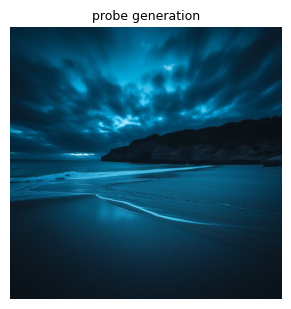

vital heads: 66 | layers: 22


,layer,head,mean_entropy,std_entropy,mean_stability,calls
797,transformer_blocks.3.attn,5,0.296677,0.105724,0.999748,4
781,transformer_blocks.2.attn,13,0.044752,0.023036,0.998071,4
838,transformer_blocks.4.attn,22,0.444265,0.163143,0.995104,4
951,transformer_blocks.9.attn,15,0.434581,0.152979,0.990550,4
895,transformer_blocks.7.attn,7,0.287371,0.107560,0.989902,4
857,transformer_blocks.5.attn,17,0.629673,0.339133,0.988081,4
753,transformer_blocks.18.attn,9,0.445240,0.034691,0.987614,4
787,transformer_blocks.2.attn,19,0.478173,0.024677,0.984371,4
826,transformer_blocks.4.attn,10,0.285047,0.248565,0.984025,4
535,transformer_blocks.1.attn,7,0.623488,0.099936,0.982357,4


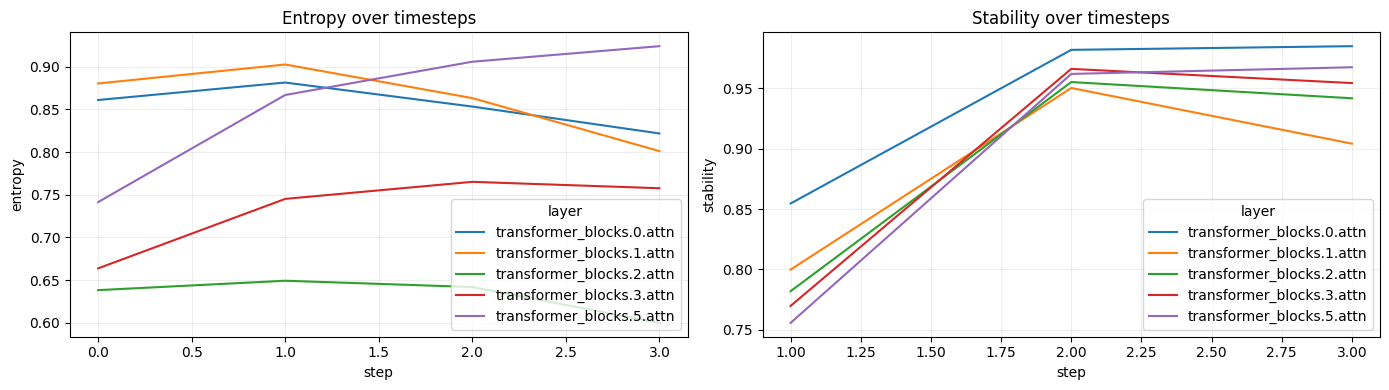

In [6]:
class AttentionProbe:
    # lightweight per-head attention statistics (entropy + temporal stability)
    def __init__(self, modules: Dict[str, torch.nn.Module], max_q_tokens: int = 96, max_k_tokens: int = 256):
        self.modules = modules
        self.max_q_tokens = int(max_q_tokens)
        self.max_k_tokens = int(max_k_tokens)
        self.step = 0
        self.records = []
        self.prev = {}
        self.handles = []

    @staticmethod
    def reshape_heads(x: torch.Tensor, heads: int):
        if x.ndim != 3:
            return None
        b, t, c = x.shape
        if c % heads != 0:
            return None
        d = c // heads
        return x.view(b, t, heads, d).permute(0, 2, 1, 3).contiguous()

    @torch.no_grad()
    def capture(self, layer: str, attn, hidden_states: torch.Tensor, encoder_hidden_states: Optional[torch.Tensor]):
        if hidden_states is None or hidden_states.ndim != 3:
            return

        kv = encoder_hidden_states if encoder_hidden_states is not None else hidden_states
        if kv.ndim != 3:
            return

        q = attn.to_q(hidden_states)[:, : self.max_q_tokens, :]
        k = attn.to_k(kv)[:, : self.max_k_tokens, :]

        heads = int(attn.heads)
        qh = self.reshape_heads(q, heads)
        kh = self.reshape_heads(k, heads)
        if qh is None or kh is None:
            return

        logits = torch.einsum("bhqd,bhkd->bhqk", qh.float(), kh.float()) / math.sqrt(qh.shape[-1])
        probs = logits.softmax(dim=-1)

        entropy = -(probs * probs.clamp_min(1e-8).log()).sum(dim=-1)
        entropy = entropy / math.log(max(probs.shape[-1], 2))
        entropy_h = entropy.mean(dim=(0, 2)).detach().cpu()

        signature = probs.mean(dim=(0, 2)).detach().cpu()
        if layer in self.prev and self.prev[layer].shape == signature.shape:
            stability_h = F.cosine_similarity(signature, self.prev[layer], dim=-1)
        else:
            stability_h = torch.full((signature.shape[0],), float("nan"))
        self.prev[layer] = signature

        for h in range(signature.shape[0]):
            self.records.append({
                "step": int(self.step),
                "layer": layer,
                "head": int(h),
                "entropy": float(entropy_h[h].item()),
                "stability": float(stability_h[h].item()),
            })

    def _hook(self, layer: str, attn):
        def fn(module, args, kwargs):
            hidden = args[0] if len(args) > 0 else kwargs.get("hidden_states")
            enc = kwargs.get("encoder_hidden_states") if isinstance(kwargs, dict) else None
            try:
                self.capture(layer, attn, hidden, enc)
            except Exception:
                pass
        return fn

    def register(self):
        self.remove()
        self.step = 0
        self.records = []
        self.prev = {}
        for layer, attn in self.modules.items():
            h = attn.register_forward_pre_hook(self._hook(layer, attn), with_kwargs=True)
            self.handles.append(h)

    def remove(self):
        for h in self.handles:
            h.remove()
        self.handles = []

    def callback_on_step_end(self, pipe, step_index: int, timestep, callback_kwargs):
        self.step = int(step_index) + 1
        return callback_kwargs

    def to_df(self):
        return pd.DataFrame(self.records, columns=["step", "layer", "head", "entropy", "stability"])


def run_probe_generation(prompt: str, src_image: Optional[Image.Image] = None):
    if pipe_t2i is None:
        raise RuntimeError("Pipeline is not loaded")

    probe = AttentionProbe(attn_modules, max_q_tokens=cfg.max_q_tokens, max_k_tokens=cfg.max_k_tokens)
    probe.register()

    t0 = time.perf_counter()
    try:
        if pipe_i2i is not None and src_image is not None:
            kwargs = dict(
                prompt=prompt,
                image=src_image,
                strength=float(cfg.strength),
                num_inference_steps=int(cfg.num_steps),
                guidance_scale=float(cfg.guidance_scale),
                generator=make_cpu_generator(cfg.seed),
            )
            kwargs = attach_callback_if_supported(pipe_i2i, kwargs, probe.callback_on_step_end)
            out = pipe_i2i(**kwargs).images[0]
        else:
            kwargs = dict(
                prompt=prompt,
                width=int(cfg.width),
                height=int(cfg.height),
                num_inference_steps=int(cfg.num_steps),
                guidance_scale=float(cfg.guidance_scale),
                generator=make_cpu_generator(cfg.seed),
            )
            kwargs = attach_callback_if_supported(pipe_t2i, kwargs, probe.callback_on_step_end)
            out = pipe_t2i(**kwargs).images[0]
    finally:
        probe.remove()

    dt = time.perf_counter() - t0
    return out, probe.to_df(), dt


attn_df = pd.DataFrame(columns=["step", "layer", "head", "entropy", "stability"])
head_stats = pd.DataFrame()
vital_df = pd.DataFrame()
vital_heads_map = {}

if cfg.run_heavy and cfg.collect_attention_stats and pipe_t2i is not None and attn_modules:
    probe_prompt = cfg.attention_probe_prompt
    probe_src = None

    if subset:
        sid, item = next(iter(subset.items()))
        src_prompt, tgt_prompt = normalize_prompts(item)
        probe_prompt = tgt_prompt or src_prompt or probe_prompt
        ip = item.get("image_path", "")
        if ip:
            try:
                probe_src = Image.open(resolve_image_path(ip, cfg.pie_root)).convert("RGB")
                if pipe_i2i is None:
                    cfg.width, cfg.height = probe_src.width, probe_src.height
            except Exception as e:
                print("[warn] cannot load source for probe:", e)

    probe_img, attn_df, probe_time = run_probe_generation(probe_prompt, probe_src)
    print("Probe done in", round(probe_time, 2), "sec | records:", len(attn_df))
    show_images([probe_img], ["probe generation"], cols=1)

    if not attn_df.empty:
        head_stats = (
            attn_df.groupby(["layer", "head"], as_index=False)
            .agg(
                mean_entropy=("entropy", "mean"),
                std_entropy=("entropy", "std"),
                mean_stability=("stability", "mean"),
                calls=("entropy", "size"),
            )
            .fillna({"std_entropy": 0.0, "mean_stability": 0.0})
        )

        st_thr = head_stats["mean_stability"].quantile(0.75)
        en_thr = head_stats["mean_entropy"].quantile(0.35)

        vital_df = head_stats[(head_stats["mean_stability"] >= st_thr) & (head_stats["mean_entropy"] <= en_thr)].copy()
        vital_heads_map = (
            vital_df.sort_values(["layer", "head"])
            .groupby("layer")["head"]
            .apply(list)
            .to_dict()
        )

        print("vital heads:", len(vital_df), "| layers:", len(vital_heads_map))
        display(vital_df.sort_values(["mean_stability", "mean_entropy"], ascending=[False, True]).head(20))

        top_layers = attn_df.groupby("layer")["stability"].mean().sort_values(ascending=False).head(5).index.tolist()
        plot_df = attn_df[attn_df["layer"].isin(top_layers)]
        if not plot_df.empty:
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            p1 = plot_df.groupby(["step", "layer"], as_index=False)["entropy"].mean()
            p2 = plot_df.groupby(["step", "layer"], as_index=False)["stability"].mean()
            sns.lineplot(data=p1, x="step", y="entropy", hue="layer", ax=axes[0])
            sns.lineplot(data=p2, x="step", y="stability", hue="layer", ax=axes[1])
            axes[0].set_title("Entropy over timesteps")
            axes[1].set_title("Stability over timesteps")
            for ax in axes:
                ax.grid(alpha=0.2)
            plt.tight_layout()
            plt.show()
else:
    print("Attention probe skipped")


In [7]:
class SharedKVController:
    # selective sharing of K/V from style anchor (batch idx 0) to other batch items
    def __init__(self, head_map: Dict[str, List[int]], total_steps: int, step_window=(0.15, 0.75), share_values=True):
        self.head_map = head_map
        self.total_steps = max(1, int(total_steps))
        self.step_window = step_window
        self.share_values = share_values
        self.step = 0
        self.handles = []

    def active(self):
        if self.total_steps <= 1:
            return True
        frac = self.step / float(self.total_steps - 1)
        return self.step_window[0] <= frac <= self.step_window[1]

    def _make_hook(self, layer: str, heads: int):
        chosen = sorted({h for h in self.head_map.get(layer, []) if 0 <= h < heads})
        if not chosen:
            return None
        idx_cpu = torch.tensor(chosen, dtype=torch.long)

        def hook(module, args, output):
            if not isinstance(output, torch.Tensor) or output.ndim != 3:
                return output
            if output.shape[0] < 2 or not self.active():
                return output

            b, t, c = output.shape
            if c % heads != 0:
                return output

            d = c // heads
            out = output.view(b, t, heads, d)
            idx = idx_cpu.to(out.device)
            src = out[0:1, :, idx, :]
            out[1:, :, idx, :] = src.expand(b - 1, -1, -1, -1)
            return out.view(b, t, c)

        return hook

    def register(self, attn_modules: Dict[str, torch.nn.Module]):
        self.remove()
        self.step = 0

        for layer, attn in attn_modules.items():
            if layer not in self.head_map:
                continue

            heads = int(getattr(attn, "heads", 0))
            if heads <= 0:
                continue

            hk = self._make_hook(layer, heads)
            if hk is not None:
                self.handles.append(attn.to_k.register_forward_hook(hk))

            if self.share_values:
                hv = self._make_hook(layer, heads)
                if hv is not None:
                    self.handles.append(attn.to_v.register_forward_hook(hv))

    def remove(self):
        for h in self.handles:
            h.remove()
        self.handles = []

    def callback_on_step_end(self, pipe, step_index: int, timestep, callback_kwargs):
        self.step = int(step_index) + 1
        return callback_kwargs


def build_all_heads_map(attn_modules: Dict[str, torch.nn.Module]) -> Dict[str, List[int]]:
    out = {}
    for layer, m in attn_modules.items():
        h = int(getattr(m, "heads", 0))
        if h > 0:
            out[layer] = list(range(h))
    return out


def build_vital_or_fallback(attn_modules: Dict[str, torch.nn.Module], vital_map: Dict[str, List[int]]) -> Dict[str, List[int]]:
    if vital_map:
        return dict(vital_map)

    fallback = {}
    for layer, m in list(attn_modules.items())[: min(6, len(attn_modules))]:
        h = int(getattr(m, "heads", 0))
        fallback[layer] = list(range(min(h, 4)))
    return fallback


In [8]:
# Metrics block (no runtime installs):
# CLIP backend priority: openai-clip -> transformers CLIP -> NaN fallback

import os
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

try:
    import clip as openai_clip
except Exception as e:
    openai_clip = None
    print("[warn] openai-clip import failed:", e)

try:
    from transformers import CLIPModel, CLIPProcessor
except Exception as e:
    CLIPModel = None
    CLIPProcessor = None
    print("[warn] transformers CLIP import failed:", e)

try:
    import lpips
except Exception as e:
    lpips = None
    print("[warn] lpips import failed:", e)

import torchvision.transforms as T


def init_metric_models(device: str):
    bundle = {}

    if openai_clip is not None:
        try:
            clip_model, clip_preprocess = openai_clip.load("ViT-B/32", device=device)
            bundle["clip_backend"] = "openai_clip"
            bundle["clip_model"] = clip_model
            bundle["clip_preprocess"] = clip_preprocess
        except Exception as e:
            print("[warn] openai-clip init failed:", e)

    if "clip_backend" not in bundle and CLIPModel is not None and CLIPProcessor is not None:
        try:
            clip_id = "openai/clip-vit-base-patch32"
            model = CLIPModel.from_pretrained(clip_id).to(device)
            processor = CLIPProcessor.from_pretrained(clip_id)
            model.eval()
            bundle["clip_backend"] = "hf_clip"
            bundle["clip_model_hf"] = model
            bundle["clip_processor"] = processor
        except Exception as e:
            print("[warn] transformers CLIP init failed:", e)

    if "clip_backend" not in bundle:
        print("[warn] No CLIP backend available: CLIP metrics will be NaN")

    if lpips is not None:
        bundle["lpips"] = lpips.LPIPS(net="alex").to(device)

    return bundle


def _normalize_feat(x: torch.Tensor):
    return x / (x.norm(dim=-1, keepdim=True) + 1e-8)


def _clip_img_feat(bundle: Dict[str, Any], image: Image.Image, device: str):
    backend = bundle.get("clip_backend")

    if backend == "openai_clip":
        model = bundle["clip_model"]
        preprocess = bundle["clip_preprocess"]
        t = preprocess(image).unsqueeze(0).to(device)
        with torch.no_grad():
            f = model.encode_image(t)
        return _normalize_feat(f)

    if backend == "hf_clip":
        model = bundle["clip_model_hf"]
        processor = bundle["clip_processor"]
        inp = processor(images=image, return_tensors="pt")
        inp = {k: v.to(device) for k, v in inp.items()}
        with torch.no_grad():
            f = model.get_image_features(**inp)
        return _normalize_feat(f)

    return None


def _clip_txt_feat(bundle: Dict[str, Any], text: str, device: str):
    if not text:
        return None

    backend = bundle.get("clip_backend")

    if backend == "openai_clip":
        model = bundle["clip_model"]
        tt = openai_clip.tokenize([text]).to(device)
        with torch.no_grad():
            f = model.encode_text(tt)
        return _normalize_feat(f)

    if backend == "hf_clip":
        model = bundle["clip_model_hf"]
        processor = bundle["clip_processor"]
        inp = processor(text=[text], return_tensors="pt", padding=True, truncation=True)
        inp = {k: v.to(device) for k, v in inp.items()}
        with torch.no_grad():
            f = model.get_text_features(**inp)
        return _normalize_feat(f)

    return None


def clip_text_similarity(bundle: Dict[str, Any], image: Image.Image, text: str, device: str) -> float:
    fi = _clip_img_feat(bundle, image, device)
    ft = _clip_txt_feat(bundle, text, device)
    if fi is None or ft is None:
        return float("nan")
    with torch.no_grad():
        return float((fi * ft).sum(dim=-1).item())


def clip_image_similarity(bundle: Dict[str, Any], img1: Image.Image, img2: Image.Image, device: str) -> float:
    f1 = _clip_img_feat(bundle, img1, device)
    f2 = _clip_img_feat(bundle, img2, device)
    if f1 is None or f2 is None:
        return float("nan")
    with torch.no_grad():
        return float((f1 * f2).sum(dim=-1).item())


def clip_directional_similarity(bundle: Dict[str, Any], src_img: Image.Image, out_img: Image.Image, src_text: str, tgt_text: str, device: str) -> float:
    if not src_text or not tgt_text:
        return float("nan")

    fi_src = _clip_img_feat(bundle, src_img, device)
    fi_out = _clip_img_feat(bundle, out_img, device)
    ft_src = _clip_txt_feat(bundle, src_text, device)
    ft_tgt = _clip_txt_feat(bundle, tgt_text, device)

    if fi_src is None or fi_out is None or ft_src is None or ft_tgt is None:
        return float("nan")

    with torch.no_grad():
        di = fi_out - fi_src
        dt = ft_tgt - ft_src

        di = di / (di.norm(dim=-1, keepdim=True) + 1e-8)
        dt = dt / (dt.norm(dim=-1, keepdim=True) + 1e-8)

        return float((di * dt).sum(dim=-1).item())


def lpips_distance(bundle: Dict[str, Any], img1: Image.Image, img2: Image.Image, device: str, size=(256, 256)) -> float:
    if "lpips" not in bundle:
        return float("nan")

    tr = T.Compose([
        T.Resize(size, interpolation=T.InterpolationMode.BICUBIC),
        T.ToTensor(),
    ])

    t1 = tr(img1.convert("RGB")).unsqueeze(0).to(device)
    t2 = tr(img2.convert("RGB")).unsqueeze(0).to(device)

    t1 = t1 * 2 - 1
    t2 = t2 * 2 - 1

    with torch.no_grad():
        d = bundle["lpips"](t1, t2)
    return float(d.item())


def mean_abs_delta(src_img: Image.Image, out_img: Image.Image, mask: Optional[np.ndarray] = None) -> Tuple[float, float]:
    a = np.asarray(src_img.convert("RGB"), dtype=np.float32) / 255.0
    b = np.asarray(out_img.convert("RGB"), dtype=np.float32) / 255.0

    if a.shape != b.shape:
        b = np.asarray(out_img.convert("RGB").resize((a.shape[1], a.shape[0]), Image.BICUBIC), dtype=np.float32) / 255.0

    d = np.abs(a - b).mean(axis=-1)

    if mask is None:
        return float(d.mean()), float("nan")

    m = mask.astype(bool)
    if m.shape != d.shape:
        m = np.array(Image.fromarray(mask.astype(np.uint8) * 255).resize((d.shape[1], d.shape[0]), Image.NEAREST)) > 0

    inside = float(d[m].mean()) if m.any() else float("nan")
    outside = float(d[~m].mean()) if (~m).any() else float("nan")
    return inside, outside


metrics_bundle = init_metric_models(cfg.device)
print("Metric models:", list(metrics_bundle.keys()))


[warn] openai-clip import failed: No module named 'clip'
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/jovyan/.mlspace/envs/nyuchelysheva_rf_inversion/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jovyan/.mlspace/envs/nyuchelysheva_rf_inversion/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/jovyan/.mlspace/envs/nyuchelysheva_rf_inversion/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
Metric models: ['clip_backend', 'clip_model_hf', 'clip_processor', 'lpips']


In [9]:
def run_flux_edit(prompt: str, seed: int, src_image: Optional[Image.Image], controller=None) -> Image.Image:
    if pipe_t2i is None:
        raise RuntimeError("Pipeline not loaded")

    g = make_cpu_generator(seed)

    if pipe_i2i is not None and src_image is not None:
        kwargs = dict(
            prompt=prompt,
            image=src_image,
            strength=float(cfg.strength),
            num_inference_steps=int(cfg.num_steps),
            guidance_scale=float(cfg.guidance_scale),
            generator=g,
        )
        if controller is not None:
            kwargs = attach_callback_if_supported(pipe_i2i, kwargs, controller.callback_on_step_end)
        out = pipe_i2i(**kwargs)
        return out.images[0]

    kwargs = dict(
        prompt=prompt,
        width=int(cfg.width),
        height=int(cfg.height),
        num_inference_steps=int(cfg.num_steps),
        guidance_scale=float(cfg.guidance_scale),
        generator=g,
    )
    if controller is not None:
        kwargs = attach_callback_if_supported(pipe_t2i, kwargs, controller.callback_on_step_end)
    out = pipe_t2i(**kwargs)
    return out.images[0]


def build_experiment_plan(attn_modules, vital_heads_map):
    all_heads_map = build_all_heads_map(attn_modules)
    vital_or_fallback = build_vital_or_fallback(attn_modules, vital_heads_map)

    return [
        {
            "name": "baseline_identity",
            "group": "baseline",
            "architecture": "No generation (copy source image)",
            "controller": None,
            "head_map": None,
            "notes": "Non-DL sanity reference",
        },
        {
            "name": "flux_plain",
            "group": "dl",
            "architecture": "FLUX.1-schnell, plain generation",
            "controller": None,
            "head_map": None,
            "notes": "Base diffusion run",
        },
        {
            "name": "flux_shared_all_heads",
            "group": "dl",
            "architecture": "FLUX + shared K/V for all heads",
            "controller": "shared_kv",
            "head_map": all_heads_map,
            "notes": "Aggressive sharing ablation",
        },
        {
            "name": "flux_shared_vital_heads",
            "group": "dl",
            "architecture": "FLUX + shared K/V for vital heads",
            "controller": "shared_kv",
            "head_map": vital_or_fallback,
            "notes": "Selective sharing (main hypothesis)",
        },
    ]


per_sample_records = []
preview_by_method = {}

if subset:
    methods = build_experiment_plan(attn_modules, vital_heads_map)

    if cfg.run_heavy and pipe_t2i is None:
        raise RuntimeError("RUN_HEAVY=True, but pipeline failed to load")

    for method in methods:
        mname = method["name"]
        print("\n===", mname, "===")

        controller = None
        if method.get("controller") == "shared_kv":
            hm = method.get("head_map", {})
            controller = SharedKVController(hm, total_steps=cfg.num_steps, step_window=(0.15, 0.75), share_values=True)
            controller.register(attn_modules)

        method_images = []

        try:
            for idx, (sid, item) in enumerate(subset.items()):
                src_prompt, tgt_prompt = normalize_prompts(item)
                prompt = tgt_prompt or src_prompt

                src_img = None
                ip = item.get("image_path", "")
                if ip:
                    try:
                        src_img = Image.open(resolve_image_path(ip, cfg.pie_root)).convert("RGB")
                    except Exception:
                        src_img = None

                mask = None
                if src_img is not None:
                    mask = decode_mask_generic(item.get("mask"), (src_img.height, src_img.width))

                t0 = time.perf_counter()
                if mname == "baseline_identity":
                    if src_img is None:
                        # fallback, если нет source image
                        out_img = Image.new("RGB", (cfg.width, cfg.height), (127, 127, 127))
                    else:
                        out_img = src_img.copy()
                else:
                    if not cfg.run_heavy:
                        continue
                    out_img = run_flux_edit(prompt=prompt, seed=cfg.seed + idx, src_image=src_img, controller=controller)
                dt = time.perf_counter() - t0

                if src_img is None:
                    src_img = out_img.copy()

                clip_t = clip_text_similarity(metrics_bundle, out_img, prompt, cfg.device)
                clip_i = clip_image_similarity(metrics_bundle, src_img, out_img, cfg.device)
                clip_dir = clip_directional_similarity(metrics_bundle, src_img, out_img, src_prompt, prompt, cfg.device)
                lp = lpips_distance(metrics_bundle, src_img, out_img, cfg.device)
                d_in, d_out = mean_abs_delta(src_img, out_img, mask)

                rec = {
                    "method": mname,
                    "group": method["group"],
                    "sample_id": sid,
                    "editing_type": item.get("editing_type_id", item.get("edit_type", np.nan)),
                    "src_prompt": src_prompt,
                    "tgt_prompt": prompt,
                    "clip_text": clip_t,
                    "clip_img_preserve": clip_i,
                    "clip_directional": clip_dir,
                    "lpips_src": lp,
                    "delta_inside_mask": d_in,
                    "delta_outside_mask": d_out,
                    "inference_time_sec": dt,
                    "fit_time_sec": 0.0,
                }
                per_sample_records.append(rec)

                if len(method_images) < 4:
                    method_images.append(out_img)

        finally:
            if controller is not None:
                controller.remove()

        preview_by_method[mname] = method_images

        # memory hygiene
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

else:
    print("[warn] Empty subset. Check PIE root and mapping files.")


per_sample_df = pd.DataFrame(per_sample_records)
print("Per-sample rows:", len(per_sample_df))
display(per_sample_df.head(20))



=== baseline_identity ===

=== flux_plain ===


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

...

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Per-sample rows: 40


,method,group,sample_id,editing_type,src_prompt,tgt_prompt,clip_text,clip_img_preserve,clip_directional,lpips_src,delta_inside_mask,delta_outside_mask,inference_time_sec,fit_time_sec
0,baseline_identity,baseline,321000000005,3,[an elephant] walking on the beach with a dark...,a beach under a dark sky,0.160416,1.000000,0.000000,0.000000,0.000000,0.000000,0.000130,0.0
1,baseline_identity,baseline,424000000000,4,the [dimly] illuminated earth,the [sunlit] illuminated earth,0.284402,1.000000,0.000000,0.000000,0.000000,0.000000,0.000080,0.0
2,baseline_identity,baseline,224000000002,2,a dog lying on the grass,a dog lying on the grass [with flowers],0.255849,1.000000,0.000000,0.000000,0.000000,0.000000,0.000084,0.0
3,baseline_identity,baseline,711000000003,7,a deer with large antlers in low polygonal style,a [iron] deer [sculpture] with large antlers i...,0.303962,1.000000,0.000000,0.000000,0.000000,0.000000,0.000081,0.0
4,baseline_identity,baseline,621000000003,6,a [green] lizard is sitting on a branch,a [brown] lizard is sitting on a branch,0.275641,1.000000,0.000000,0.000000,0.000000,0.000000,0.000081,0.0
5,baseline_identity,baseline,224000000008,2,the bridge is lit up at night with fog,the bridge is lit up at night with fog [and a ...,0.241683,1.000000,0.000000,0.000000,0.000000,0.000000,0.000083,0.0
6,baseline_identity,baseline,211000000000,2,a dog wearing space suit,a dog wearing space suit [with flowers in mouth],0.334920,1.000000,0.000000,0.000000,0.000000,0.000000,0.000082,0.0
7,baseline_identity,baseline,000000000115,0,two [ducks] standing next to each other,two [birds] standing next to each other,0.286293,1.000000,0.000000,0.000000,0.000000,0.000000,0.000083,0.0
8,baseline_identity,baseline,622000000002,6,a man in a [white] shirt talking on a cell phone,a man in a [blue] shirt talking on a cell phone,0.281956,1.000000,0.000000,0.000000,0.000000,0.000000,0.000083,0.0
9,baseline_identity,baseline,822000000006,8,a woman in a dress holding an umbrella with [t...,a woman in a dress holding an umbrella with [e...,0.270932,1.000000,0.000000,0.000000,0.000000,0.000000,0.000084,0.0


baseline_identity


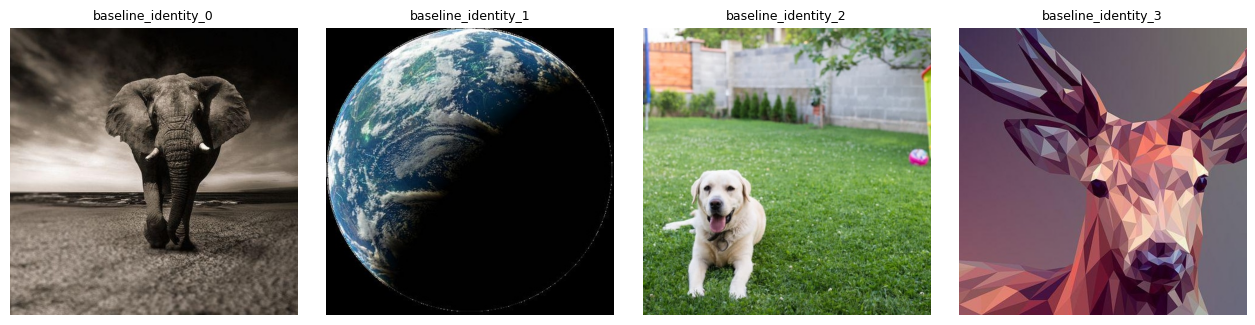

flux_plain


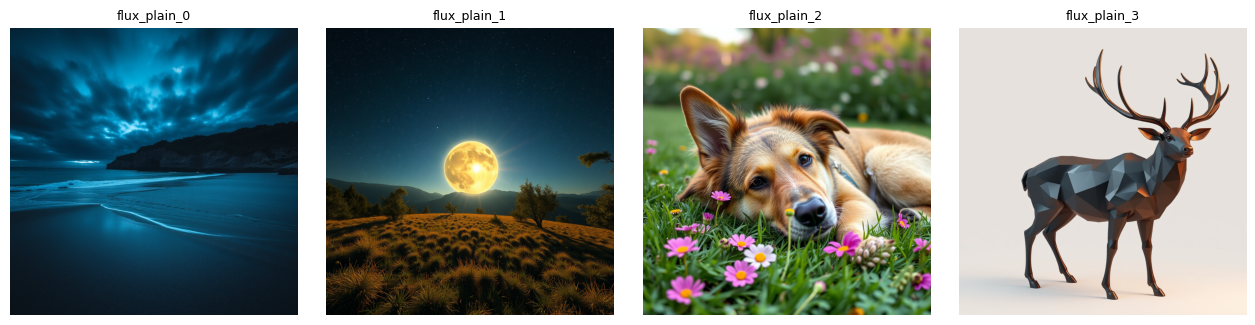

flux_shared_all_heads


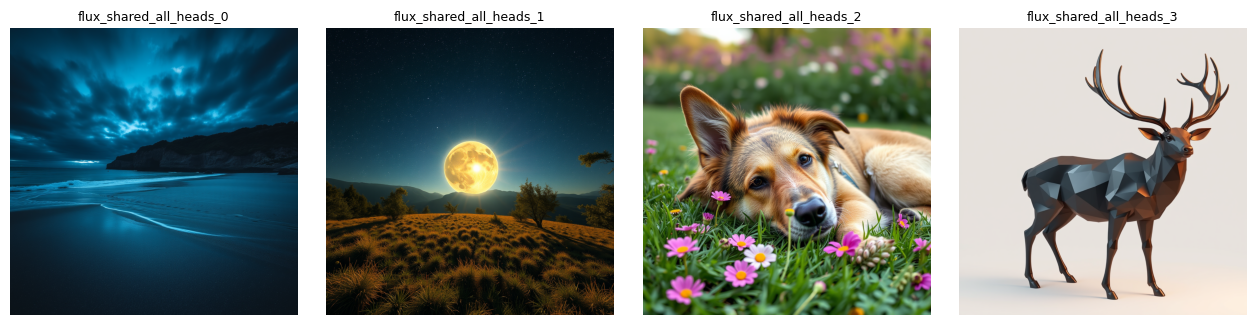

flux_shared_vital_heads


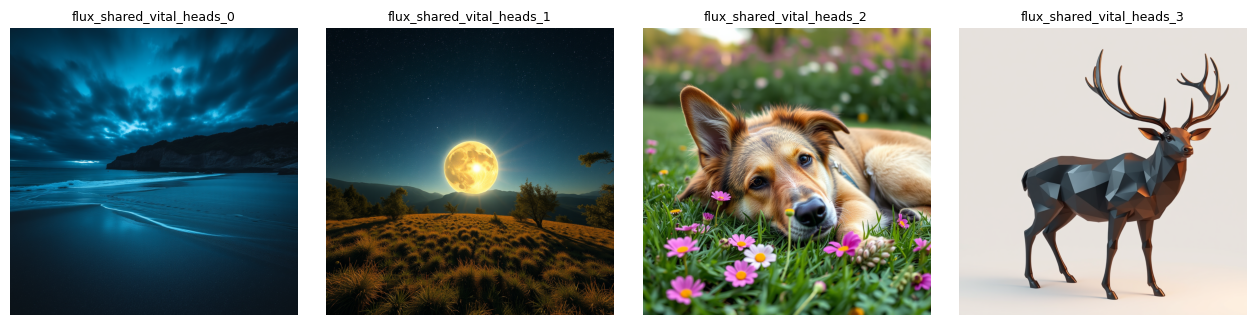

In [10]:
# Visual preview for quick sanity check
for mname, imgs in preview_by_method.items():
    if imgs:
        print(mname)
        show_images(imgs, [f"{mname}_{i}" for i in range(len(imgs))], cols=4)


DL results table:


,method,group,model,architecture,hyperparams,fit_time_sec,inference_time_sec,clip_text,clip_img_preserve,clip_directional,lpips_src,delta_inside_mask,delta_outside_mask,n_samples
0,baseline_identity,baseline,identity,No generation (copy source),"{""num_steps"": 4, ""guidance_scale"": 0.0, ""stren...",0.0,0.000087,0.269605,1.000000,0.00000,0.000000,0.00000,0.000000,10
1,flux_plain,dl,black-forest-labs/FLUX.1-schnell,FLUX.1-schnell plain,"{""num_steps"": 4, ""guidance_scale"": 0.0, ""stren...",0.0,1.432645,0.328083,0.728434,0.17115,0.721862,0.28383,0.237743,10
2,flux_shared_all_heads,dl,black-forest-labs/FLUX.1-schnell,FLUX + shared K/V all heads,"{""num_steps"": 4, ""guidance_scale"": 0.0, ""stren...",0.0,1.368409,0.328083,0.728434,0.17115,0.721862,0.28383,0.237743,10
3,flux_shared_vital_heads,dl,black-forest-labs/FLUX.1-schnell,FLUX + shared K/V vital heads,"{""num_steps"": 4, ""guidance_scale"": 0.0, ""stren...",0.0,1.397048,0.328083,0.728434,0.17115,0.721862,0.28383,0.237743,10


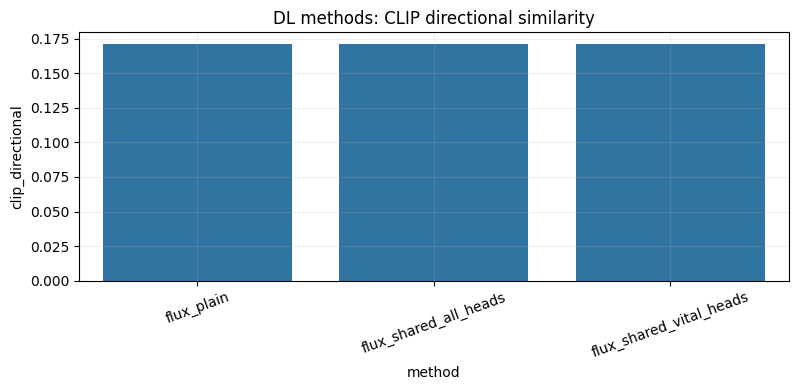

In [11]:
def agg_or_nan(series, fn="mean"):
    s = pd.to_numeric(series, errors="coerce")
    s = s.dropna()
    if s.empty:
        return float("nan")
    if fn == "mean":
        return float(s.mean())
    if fn == "std":
        return float(s.std())
    if fn == "median":
        return float(s.median())
    return float("nan")


def build_dl_results_table(per_sample_df: pd.DataFrame):
    if per_sample_df.empty:
        return pd.DataFrame()

    rows = []
    method_to_arch = {
        "baseline_identity": "No generation (copy source)",
        "flux_plain": "FLUX.1-schnell plain",
        "flux_shared_all_heads": "FLUX + shared K/V all heads",
        "flux_shared_vital_heads": "FLUX + shared K/V vital heads",
    }

    for method, gdf in per_sample_df.groupby("method"):
        row = {
            "method": method,
            "group": gdf["group"].iloc[0],
            "model": cfg.model_id if method != "baseline_identity" else "identity",
            "architecture": method_to_arch.get(method, method),
            "hyperparams": json.dumps({
                "num_steps": cfg.num_steps,
                "guidance_scale": cfg.guidance_scale,
                "strength": cfg.strength,
                "sample_count": cfg.sample_count,
                "seed": cfg.seed,
            }, ensure_ascii=False),
            "fit_time_sec": agg_or_nan(gdf["fit_time_sec"]),
            "inference_time_sec": agg_or_nan(gdf["inference_time_sec"]),
            "clip_text": agg_or_nan(gdf["clip_text"]),
            "clip_img_preserve": agg_or_nan(gdf["clip_img_preserve"]),
            "clip_directional": agg_or_nan(gdf["clip_directional"]),
            "lpips_src": agg_or_nan(gdf["lpips_src"]),
            "delta_inside_mask": agg_or_nan(gdf["delta_inside_mask"]),
            "delta_outside_mask": agg_or_nan(gdf["delta_outside_mask"]),
            "n_samples": int(len(gdf)),
        }
        rows.append(row)

    out = pd.DataFrame(rows)
    return out.sort_values(["group", "clip_directional", "clip_text"], ascending=[True, False, False]).reset_index(drop=True)


dl_results_df = build_dl_results_table(per_sample_df)
print("DL results table:")
display(dl_results_df)

if not dl_results_df.empty:
    plt.figure(figsize=(8, 4))
    plot_df = dl_results_df[dl_results_df["group"] == "dl"].copy()
    if not plot_df.empty:
        sns.barplot(data=plot_df, x="method", y="clip_directional")
        plt.xticks(rotation=20)
        plt.title("DL methods: CLIP directional similarity")
        plt.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()


In [12]:
# Таблица для baseline/ML результатов с прошлых этапов (заполните своими числами)
# Можно оставить как есть и дописать вручную после прогона.

ml_baseline_rows = [
    {
        "group": "baseline",
        "model": "Rule/Heuristic baseline",
        "architecture": "Non-neural baseline from previous checkpoint",
        "hyperparams": "{}",
        "fit_time_sec": np.nan,
        "inference_time_sec": np.nan,
        "main_metric": np.nan,
        "secondary_metric": np.nan,
        "notes": "Fill with your checkpoint-3/4 baseline metrics",
    },
    {
        "group": "ml",
        "model": "Best ML approach",
        "architecture": "Your best classical ML model",
        "hyperparams": "{}",
        "fit_time_sec": np.nan,
        "inference_time_sec": np.nan,
        "main_metric": np.nan,
        "secondary_metric": np.nan,
        "notes": "Fill with your checkpoint-4/5 ML metrics",
    },
]

ml_baseline_df = pd.DataFrame(ml_baseline_rows)
display(ml_baseline_df)


,group,model,architecture,hyperparams,fit_time_sec,inference_time_sec,main_metric,secondary_metric,notes
0,baseline,Rule/Heuristic baseline,Non-neural baseline from previous checkpoint,{},NaN,NaN,NaN,NaN,Fill with your checkpoint-3/4 baseline metrics
1,ml,Best ML approach,Your best classical ML model,{},NaN,NaN,NaN,NaN,Fill with your checkpoint-4/5 ML metrics


In [13]:
# Общая таблица сравнения baseline + ML + DL

if dl_results_df.empty:
    dl_comp = pd.DataFrame(columns=[
        "group", "model", "architecture", "hyperparams", "fit_time_sec", "inference_time_sec",
        "main_metric", "secondary_metric", "notes"
    ])
else:
    dl_comp = dl_results_df.copy()
    dl_comp = dl_comp.rename(columns={
        "clip_directional": "main_metric",
        "clip_text": "secondary_metric",
    })
    dl_comp["notes"] = "DL experiment (higher main_metric is better)"
    keep_cols = [
        "group", "model", "architecture", "hyperparams", "fit_time_sec", "inference_time_sec",
        "main_metric", "secondary_metric", "notes"
    ]
    dl_comp = dl_comp[keep_cols]

combined_df = pd.concat([ml_baseline_df, dl_comp], ignore_index=True)
combined_df = combined_df.reset_index(drop=True)

print("Combined comparison table:")
display(combined_df)

# Автовыбор лучшего DL-метода (по main_metric=clip_directional)
best_dl = pd.DataFrame()
if not dl_comp.empty:
    cand = dl_comp[dl_comp["group"] == "dl"].copy()
    cand = cand.sort_values("main_metric", ascending=False)
    best_dl = cand.head(1)

print("Best DL candidate:")
display(best_dl)


Combined comparison table:


,group,model,architecture,hyperparams,fit_time_sec,inference_time_sec,main_metric,secondary_metric,notes
0,baseline,Rule/Heuristic baseline,Non-neural baseline from previous checkpoint,{},NaN,NaN,NaN,NaN,Fill with your checkpoint-3/4 baseline metrics
1,ml,Best ML approach,Your best classical ML model,{},NaN,NaN,NaN,NaN,Fill with your checkpoint-4/5 ML metrics
2,baseline,identity,No generation (copy source),"{""num_steps"": 4, ""guidance_scale"": 0.0, ""stren...",0.0,0.000087,0.00000,0.269605,DL experiment (higher main_metric is better)
3,dl,black-forest-labs/FLUX.1-schnell,FLUX.1-schnell plain,"{""num_steps"": 4, ""guidance_scale"": 0.0, ""stren...",0.0,1.432645,0.17115,0.328083,DL experiment (higher main_metric is better)
4,dl,black-forest-labs/FLUX.1-schnell,FLUX + shared K/V all heads,"{""num_steps"": 4, ""guidance_scale"": 0.0, ""stren...",0.0,1.368409,0.17115,0.328083,DL experiment (higher main_metric is better)
5,dl,black-forest-labs/FLUX.1-schnell,FLUX + shared K/V vital heads,"{""num_steps"": 4, ""guidance_scale"": 0.0, ""stren...",0.0,1.397048,0.17115,0.328083,DL experiment (higher main_metric is better)


Best DL candidate:


,group,model,architecture,hyperparams,fit_time_sec,inference_time_sec,main_metric,secondary_metric,notes
1,dl,black-forest-labs/FLUX.1-schnell,FLUX.1-schnell plain,"{""num_steps"": 4, ""guidance_scale"": 0.0, ""stren...",0.0,1.432645,0.17115,0.328083,DL experiment (higher main_metric is better)


In [14]:
# Экспорт артефактов
cfg.output_dir.mkdir(parents=True, exist_ok=True)

saved = []

for name, df in [
    ("per_sample_metrics.csv", per_sample_df),
    ("dl_results_table.csv", dl_results_df),
    ("baseline_ml_table_template.csv", ml_baseline_df),
    ("combined_comparison_table.csv", combined_df),
    ("attention_raw.csv", attn_df),
    ("attention_head_stats.csv", head_stats),
    ("attention_vital_heads.csv", vital_df),
]:
    if isinstance(df, pd.DataFrame) and not df.empty:
        p = cfg.output_dir / name
        df.to_csv(p, index=False)
        saved.append(p)

# json с конфигом
cfg_json_path = cfg.output_dir / "run_config.json"
with open(cfg_json_path, "w", encoding="utf-8") as f:
    json.dump({k: str(v) for k, v in asdict(cfg).items()}, f, ensure_ascii=False, indent=2)
saved.append(cfg_json_path)

print("Saved artifacts:")
for p in saved:
    print("-", p)


Saved artifacts:
- results/checkpoint6/per_sample_metrics.csv
- results/checkpoint6/dl_results_table.csv
- results/checkpoint6/baseline_ml_table_template.csv
- results/checkpoint6/combined_comparison_table.csv
- results/checkpoint6/attention_raw.csv
- results/checkpoint6/attention_head_stats.csv
- results/checkpoint6/attention_vital_heads.csv
- results/checkpoint6/run_config.json


## Выводы для отчета

### Частичные выводы (уже подтверждено на текущем цикле)

1. **Attention-анализ имеет смысл и даёт интерпретируемую структуру.**
   По результатам `ML_Experiments` выделяется устойчивое подмножество `vital`-голов, и этого достаточно, чтобы строить осмысленные абляции по вмешательству в attention.

2. **Наблюдается устойчивый trade-off `style vs text`.**
   На проверочном прогоне получилось: стилевая согласованность выросла (`clip_style_ref` выше), а текстовая релевантность просела (`clip_text` ниже).
   Это не "провал" метода, а ожидаемое смещение баланса в сторону стиля при shared-attention.

3. **Главный практический вывод для чекпоинта:**
   - `shared_all_heads` обычно слишком агрессивен;
   - `shared_vital_heads` — более управляемый вариант, который лучше подходит как рабочая точка для дальнейшего тюнинга.

### Что обязательно дописать после финального прогона `DL_Experiments`

1. **Лучшая конфигурация**
   - Выбрать лучший метод по `main_metric` из `dl_results_table.csv`.
   - Указать его слабую сторону (какая метрика просела).

2. **Почему одна архитектура лучше другой**
   - Сравнить `flux_plain`, `flux_shared_all_heads`, `flux_shared_vital_heads`.
   - Объяснить разницу через степень вмешательства в attention и окно таймстепов.

3. **Сводка baseline / ML / DL**
   - Заполнить `baseline_ml_table_template.csv` числами из прошлых этапов.
   - Использовать `combined_comparison_table.csv` как финальную таблицу в отчете.

4. **Ограничения эксперимента**
   - размер выборки, число seed, вычислительные ограничения, чувствительность к параметрам вмешательства.

5. **Следующие шаги**
   - ослабить вмешательство (`K-only`/`V-only`, меньше голов, уже окно шагов);
   - проверить устойчивость на нескольких seed;
   - финально выбрать конфигурацию по балансу style-consistency и text-alignment.
